# S6 - Text and Sentiment Analysis with Python
---

Text analysis is an increasingly popular topic, and even if you have not heard about text analysis, you might have heard about sentiment analysis which is being used to analyze social media. 

This is very cumbersome if not impossible to do with tools such as excel, but relativley straightforward with python. 

In this workshop I will focus on: 

*   S6.1 - Sentiment Analysis with VADER (Python Package)
*   S6.2 - Sentiment Analysis with our own "Homebrew" algorithim. 
*   S6.3 - Evaluating the accuracy of the classifiers 
*   S6.4 - Extensions [Will be added ... need to see how far we get in session] 
    *   Subject Identification
    *   Text embeddings for Contextual Understanding
    *   Document similarity / Plagarism Detection
    








In [ ]:
# First, lets get load all of the usual packages 

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

In [1]:
from google.colab import drive       

drive.mount('/content/drive')

KeyboardInterrupt: ignored

In [ ]:
os.chdir("./drive/MyDrive/Teaching/DSO 574/Notebooks for Python Workshops/Data Files")

## S6.1 - Sentiment Analysis with Vader
---- 

Sentiment analysis is a technique to identify whether a sentance is positive or negative. It quite literaly provides you with a numerical value for how positive or negative a particular sentance may be. This is useful when you want to understand things like social media posts, consumer reviews, etc. 

We will be using the python package VADER (Valence Aware Dictionary and sEntiment Reasoner). It is very easy to use, and designed to work well with social media posts which can include emojis. 

You can find the documentation here: https://github.com/cjhutto/vaderSentiment

I always find this image helpful to remember the name of this package. 

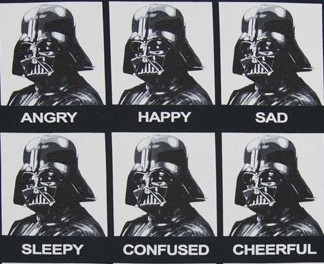


In [ ]:
# Lets first install VADER -- It is not preinstalled on Colab #

!pip install vaderSentiment


In [ ]:
# Now lets load the package # 

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

VADER itself is trivial to use. We just specify a sentance and ask this package to tell us the valence (positivity, negativity, etc.) 

Some examples below from recent tweets

In [ ]:
Sentence = "Thrilled to share that the commencement ceremony for the Class of 2020 & 2021 will be held IN-PERSON at the Los Angeles Coliseum! #TrojansTogether #FightOn #USC President Folt's official statement here: http://bit.ly/30TYSnl @USC @lacoliseum @USCAlumni"

SentimentIntensityAnalyzer().polarity_scores(Sentence)

{'compound': 0.6588, 'neg': 0.0, 'neu': 0.86, 'pos': 0.14}

In [ ]:
Sentance = "America’s Covid swab supply depends on two cousins who hate each other"

SentimentIntensityAnalyzer().polarity_scores(Sentance)

{'compound': -0.5719, 'neg': 0.252, 'neu': 0.748, 'pos': 0.0}

In [ ]:
Sentance = ":)"

SentimentIntensityAnalyzer().polarity_scores(Sentance)

{'compound': 0.4588, 'neg': 0.0, 'neu': 0.0, 'pos': 1.0}

In [ ]:
Sentance = ":("

SentimentIntensityAnalyzer().polarity_scores(Sentance)

{'compound': -0.4404, 'neg': 1.0, 'neu': 0.0, 'pos': 0.0}

In [ ]:
SentimentIntensityAnalyzer().polarity_scores("🤝")

{'compound': 0.0, 'neg': 0.0, 'neu': 1.0, 'pos': 0.0}

In [ ]:
SentimentIntensityAnalyzer().polarity_scores("😝")

{'compound': 0.0, 'neg': 0.0, 'neu': 1.0, 'pos': 0.0}

In [ ]:
# You can extract only the positive or negative by adding that in square brackets after 

SentimentIntensityAnalyzer().polarity_scores(Sentance)['neg']

1.0

So why might you want this information. Some companies charge a lot of money providing sentiment analysis of social media. This can be done virtually for free with Python. 

Also, it allows you to explore broader trends. As an example, I have uploaded a file with all tweets made by Donald Trump between 2009 and 2021. I just chose this example because we can expect that there will be a lot of positive / negative sentiment in these tweets. 

In [ ]:
tweets = pd.read_csv("./trump_tweets.csv")

In [ ]:
tweets.head()

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f


In [ ]:
tweets.shape

(56571, 9)

The dataset is pretty straightforward. Unique ID, Tweet Text, Indicators for Retweets, whether it was deleted, device and whether it was flagged. Also includes the date of the tweet, number of favourites / retweets and whether it was flagged. 

Next, I will run through all of the tweets to create a column in the data indicating whether the tweets were positive or negative. I have to loop through each of the observations so this takes a while. 

In [ ]:
# Lets do the sentiment analysis for these 56K tweets

Sent = []

for TW in tqdm(tweets[['id','text']].values.tolist()):

  id = TW[0] 

  sentiment = SentimentIntensityAnalyzer().polarity_scores(TW[1])

  Sent.append([id, sentiment['pos'], sentiment['neg'], sentiment['neu'], sentiment['compound']])



In [ ]:
tweets = tweets.merge(pd.DataFrame(Sent, columns = ['id','Pos','Neg','Neu','Compound']), on = 'id')

In [ ]:
# To see the result #

tweets.head()

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,Pos,Neg,Neu,Compound
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,0.171,0.231,0.598,-0.1779
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,0.433,0.000,0.567,0.9792
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,0.000,0.000,1.000,0.0000
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,0.000,0.288,0.712,-0.9571
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,0.143,0.000,0.857,0.5413


Now, that we have this, we can run the type of analysis we have done in other workshops. 

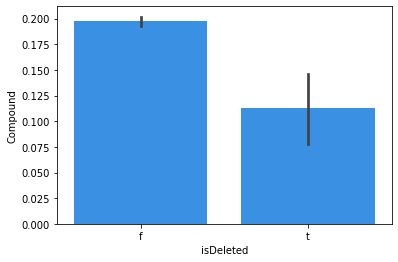

In [ ]:
# Whether those tweets that are deleted are more or less positive # 

sns.barplot(data = tweets, 
            x = 'isDeleted',
            y = 'Compound',
            color = 'DodgerBlue')

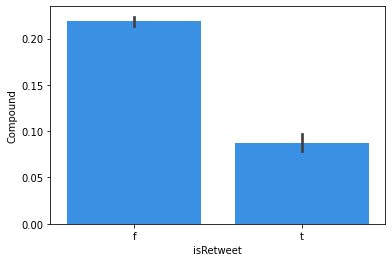

In [ ]:
# Whether original tweets or re-tweets are most positive / negative # 

sns.barplot(data = tweets, 
            x = 'isRetweet',
            y = 'Compound',
            color = 'DodgerBlue')

In [ ]:
tweets['date'] = pd.to_datetime(tweets['date'], errors= 'coerce')

In [ ]:
tweets['Year'] = tweets['date'].dt.year

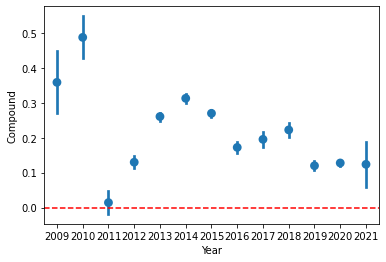

In [ ]:
# Pointplot provides the average within each year, with 90% confidence intervals based on a bootstrap # 

sns.pointplot(data = tweets, 
            x = 'Year',
            y = 'Compound',
            join = False)
plt.axhline(0,linestyle = '--', color = 'red')
plt.show()

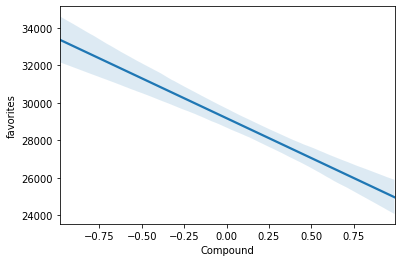

In [ ]:
# We can also explore the relationship between sentiment and whether it is retweeted, favourited # 

sns.regplot(data = tweets, 
            x = 'Compound',
            y = 'favorites', scatter = False)

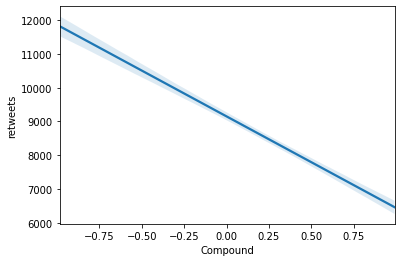

In [ ]:

sns.regplot(data = tweets, 
            x = 'Compound',
            y = 'retweets', scatter = False)

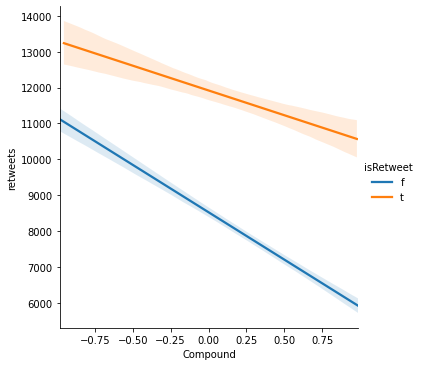

In [ ]:
# We can also compare across groups. However, we have to use the command lm #

sns.lmplot(data = tweets, 
            x = 'Compound',
            y = 'retweets',
            hue = 'isRetweet', scatter = False)

plt.show()

## S6.2 - Sentiment Analysis with our own "Homebrew" algorithim
---
We can also create our own version of VADER. You might hear me saying the term "homebrew". That is a comment that has been used for the past several decades in this IT / programming world. The most famous origin is the "Homebrew computer club" which were a bunch of folks that experimented with making their own computer at home and then went on to found Apple Computer. 


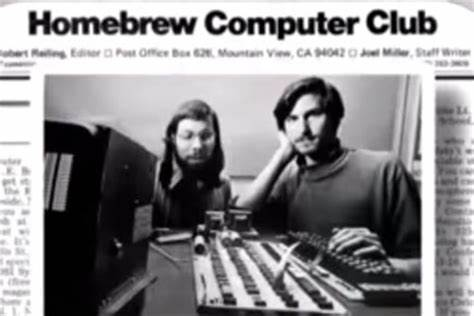



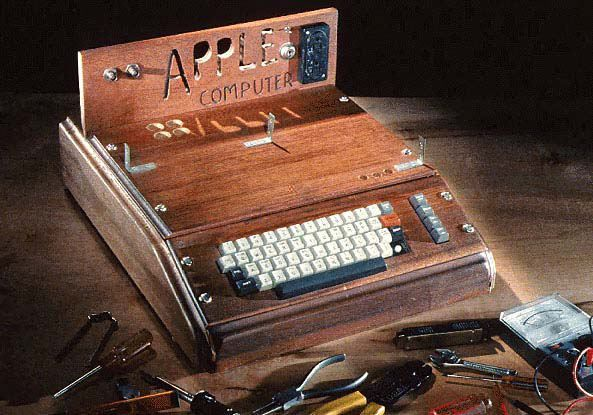

Just like them, we are going to make a very homemade version of VADER. 

To do this, we need training data. This means data where someone has already indicated whether the tweets are positive or negative. 

Luckily some poor souls at Stanford have gone through the trouble of manually classifying 1.6 million tweets as positive or negative. This data is availible here: http://help.sentiment140.com/for-students

I have uploaded both the training and test data to our google drive. 

# From the URL, it describes the file structure #

The data is a CSV with emoticons removed. Data file format has 6 fields:


*   0 - the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)
*   1 - the id of the tweet (2087)
*   2 - the date of the tweet (Sat May 16 23:58:44 UTC 2009)
*   3 - the query (lyx). If there is no query, then this value is NO_QUERY.
*   4 - the user that tweeted (robotickilldozr)
*   5 - the text of the tweet (Lyx is cool)












In [ ]:
# import training data # 

training = pd.read_csv("./training.1600000.processed.noemoticon.csv", encoding ='latin1', names = ['Polarity', 'id', 'Date', 'Q', 'Author', 'Tweet'])

In [ ]:
training.head()

,Polarity,id,Date,Q,Author,Tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# To understand the polarity # 

training['Polarity'].value_counts()

4    800000
0    800000
Name: Polarity, dtype: int64

In [ ]:
# Lets create a more intuitive variable. 1 if positive # 

training['Positive'] = np.where(training['Polarity'] == 4, 1, 0)

Here is the process for constructing the "sentiment analysis" 

1. Convert Tweets to Term-Frequency matrix
2. Use columns in Term-Frequency Matrix (Features) as variables in a statistical model to predict positivity. 
3. Use that model to predict on other data. 


What is a Term-Frequency matrix? 

Its a table, with the documents (sentances) along the rows (row names) and words along the columns (column names). The fields in the table corespond to how many times this word appears in that document (ie. its frequency). 

Below is an illustration. Unfortunatley Icouldnt find a perfect one. This is basically a Term-Frequency matrix but on its side (the rows / columns are reversed). 


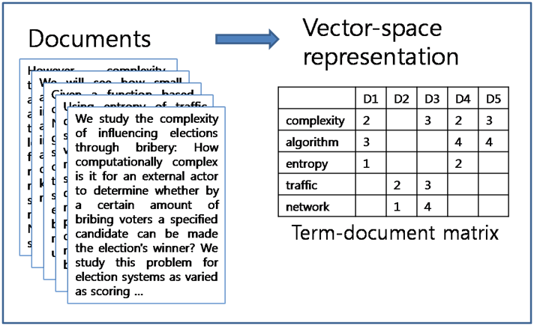

In [ ]:
# Let's load the VECTORIZER ( a tool that take a list of sentances and fits them right in this structure) #

from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(max_df = .9, min_df = 0.05, lowercase=True)


We are goign to specify three options: 


*   **Max DF:** What is the maximum number of documents that a word needs to appear in to be omitted. This helps us get rid of words like:* a, the, and*
*   **Min DF:** What is the minimum number of documents that a word needs to appear in to be included. This helps us get rid of rare words that dont occur frequently. 
*   **Lowercase:** We want all of the words converted to lowercase. 





In [ ]:
# There are lots of other options -- https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer #

vec

CountVectorizer(analyzer='word', binary=False, decode_error='strict',
                dtype=<class 'numpy.int64'>, encoding='utf-8', input='content',
                lowercase=True, max_df=0.9, max_features=None, min_df=0.05,
                ngram_range=(1, 1), preprocessor=None, stop_words=None,
                strip_accents=None, token_pattern='(?u)\\b\\w\\w+\\b',
                tokenizer=None, vocabulary=None)

In [ ]:
TFMatrix = vec.fit_transform(training['Tweet'].values.tolist())

In [ ]:
# To see how many words we got #

TFMatrix.shape

(1600000, 29)

In [ ]:
# 29 words is not a lot, so maybe lets just check what they are # 

vec.get_feature_names()

['all',
 'and',
 'at',
 'be',
 'but',
 'can',
 'day',
 'for',
 'good',
 'have',
 'in',
 'is',
 'it',
 'just',
 'me',
 'my',
 'not',
 'now',
 'of',
 'on',
 'so',
 'that',
 'the',
 'this',
 'to',
 'up',
 'was',
 'with',
 'you']

In [ ]:
# Let's adjust our command. We want a lower Max_DF to get rid of some of these like "and", and we also want more words so lets just set the number of words we want #

vec = CountVectorizer(max_df = .2, max_features= 500, lowercase=True)

TFMatrix = vec.fit_transform(training['Tweet'].values.tolist())

In [ ]:
# Let's get a list of the top features # 

pd.DataFrame(list(zip(vec.get_feature_names(),TFMatrix.sum(axis = 0).tolist()[0])), columns = ['words', 'frequency']).sort_values('frequency', ascending = False).head(20)

,words,frequency
278,my,316829
214,it,304769
19,and,303603
498,you,302036
212,is,238328
208,in,216560
129,for,216348
293,of,183804
301,on,168356
396,that,165910


Next, we are going to run a regression model. Imagine that we have the following specification: 

Y = a + BX 

where

*   Y is the positive negative sentiment, manually coded. 
*   X is the matrix of values
*   B is actually a bunch of beta coefficients that we will estimate for each word. 

Based on the B's we will see how positive / negative each word will be. We will also be able to use that to predict other tweet values. 



In [ ]:
# We will just use linear regression as described above. This could work with any model, including really complex stuff like Neural networks. #

from sklearn.linear_model import LinearRegression


In [ ]:
reg = LinearRegression().fit(TFMatrix, training['Positive'].values.tolist())

coeficients = reg.coef_

# First 20 Coefs. 

coeficients[:20]

array([-0.0025018 , -0.04446288, -0.09318112, -0.00572067,  0.06292769,
        0.00501428, -0.05337193, -0.02746536,  0.04099434, -0.00177114,
       -0.00833161, -0.16547499, -0.05047795,  0.04301944,  0.03626947,
       -0.02277731,  0.17479242,  0.03382474,  0.01465322,  0.01632317])

In [ ]:
# We can also get an estimate of what are the most positive words. #

pd.DataFrame(list(zip(vec.get_feature_names(),TFMatrix.sum(axis = 0).tolist()[0],coeficients)), columns = ['words', 'frequency','coef']).sort_values('coef', ascending = False).head(10)

,words,frequency,coef
463,welcome,7324,0.251270
395,thanks,40329,0.246298
112,excited,9817,0.232885
182,hehe,5015,0.218551
155,goodnight,5533,0.213240
491,yay,13684,0.212425
148,glad,10530,0.204784
394,thank,18114,0.203004
79,cute,7797,0.200845
30,awesome,18286,0.196356


In [ ]:
# And most negative #

pd.DataFrame(list(zip(vec.get_feature_names(),TFMatrix.sum(axis = 0).tolist()[0],coeficients)), columns = ['words', 'frequency','coef']).sort_values('coef', ascending = False).tail(20)

,words,frequency,coef
87,didnt,6614,-0.191241
130,forgot,5465,-0.195590
51,boo,5242,-0.218950
436,ugh,10047,-0.226514
329,raining,5076,-0.227112
202,hurt,5202,-0.228084
358,sick,16033,-0.240903
172,hate,19819,-0.246621
377,stuck,4967,-0.248812
477,wish,28282,-0.249521


We could classify the Trump tweets using the same technique 



In [ ]:
# Train the model on the Stanford Twitter Data # 

vec = CountVectorizer(max_df = .2, max_features= 500, lowercase=True)

TFMatrix = vec.fit_transform(training['Tweet'].values.tolist())

words_in_training_data = vec.get_feature_names()

reg = LinearRegression().fit(TFMatrix, training['Positive'].values.tolist())

# Load the Trump tweets and convert to TFMatrix format # 

vec = CountVectorizer(vocabulary=words_in_training_data)

TF_TRUMP_Matrix = vec.fit_transform(tweets['text'].values.tolist())

Predictions = reg.predict(TF_TRUMP_Matrix)

In [ ]:
tweets['Predictions'] = Predictions

In [ ]:
tweets.head()

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,Pos,Neg,Neu,Compound,Year,Predictions
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,0.171,0.231,0.598,-0.1779,2011,0.526450
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,0.433,0.000,0.567,0.9792,2020,1.286844
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,0.000,0.000,1.000,0.0000,2020,0.469323
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,0.000,0.288,0.712,-0.9571,2020,0.088571
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,0.143,0.000,0.857,0.5413,2020,0.640375


 We

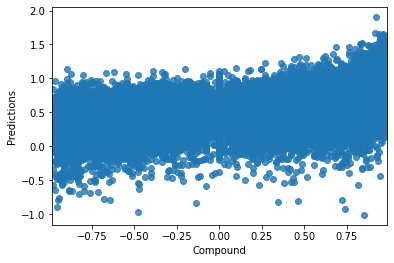

In [ ]:
sns.regplot(data = tweets, 
                x = 'Compound', 
                y = 'Predictions')

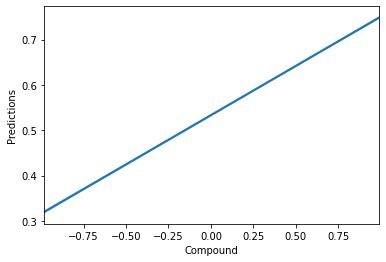

In [ ]:
sns.regplot(data = tweets, 
                x = 'Compound', 
                y = 'Predictions', scatter = False)

There is a positive relationship between our prediction and the VADER analysis. However, there are also some obvious limitations. 

*   Our predicted values go above 1. This does not make sense, and it happens because we are using an OLS model with a 1/0 outcome variable. 
*   Our tweets seem more positive and not centered around zero, while the VADER ones do. 

There are lots of things we could do to improve: 

*   Select better features (words)
*   Select a better model
*   Take into account pairs of words (e.g. 'not good')

#### Important question: How do we know if our model is any good?



### 6.3 - Validating the performance of our Sentiment Analysis Tool 

--- 

To see how well our model works, we need to use "validation" data or test data. 

This is basically a part of the data we are not going to use for training the model, but we will use for testing the accuracy of our predictions. 

Python has a lot of clever (and much more reliable ways) of splitting the data into a train / test sample. You can find these here: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection

I will just do this with the .head() .tail() command for illustrative purposes. 


In [ ]:
# We need to first scramble the data because it was organized as negative tweets first, then positive tweets. This just shuffles the deck # 

training2 = training.sample(frac=1).reset_index(drop=True)

In [ ]:
# Since we have 1.6 million observations. Lets use 10K for test and the rest for training # 

TrainingDataV2 = training2.head(1590000)

TestData = training2.tail(10000)

In [ ]:
# Run the Model on the Training Data # 

vec = CountVectorizer(max_df = .2, max_features= 500, lowercase=True)

TFMatrix = vec.fit_transform(TrainingDataV2['Tweet'].values.tolist())

words_in_training_data = vec.get_feature_names()

reg = LinearRegression().fit(TFMatrix, TrainingDataV2['Positive'].values.tolist())

In [ ]:
# Run the Model on the Test Data # 

vec = CountVectorizer(vocabulary=words_in_training_data)

TF_TEST_Matrix = vec.fit_transform(TestData['Tweet'].values.tolist())

Predictions = reg.predict(TF_TEST_Matrix)

TestData['Homebrew P'] = Predictions

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


In [ ]:
# Run the Vader Sentiment Analysis Tool of the Same Tweets # 

Sent = []

for TW in tqdm(TestData[['id','Tweet']].values.tolist()):

  id = TW[0] 

  sentiment = SentimentIntensityAnalyzer().polarity_scores(TW[1])

  Sent.append([id, sentiment['pos'], sentiment['neg'], sentiment['neu'], sentiment['compound']])


TestData = TestData.merge(pd.DataFrame(Sent, columns = ['id','Pos','Neg','Neu','Compound']), on = 'id')

In [ ]:
# Let's take a quick look at the data # 

TestData.head()

,Polarity,id,Date,Q,Author,Tweet,Positive,Homebrew P,Pos,Neg,Neu,Compound
0,4,1989285171,Mon Jun 01 00:59:45 PDT 2009,NO_QUERY,FotoWala,@jeffnewsom super cute I just linked to your ...,1,0.993052,0.385,0.000,0.615,0.7845
1,0,2208225410,Wed Jun 17 08:56:13 PDT 2009,NO_QUERY,purpleandgold,@tiffychua The registration is over already?!?...,0,0.123657,0.000,0.382,0.618,-0.6526
2,4,1881476228,Fri May 22 04:46:20 PDT 2009,NO_QUERY,nadinka22,Back home from school. Friday! Out tonight. Ca...,1,0.755947,0.000,0.000,1.000,0.0000
3,0,2232796898,Thu Jun 18 20:24:27 PDT 2009,NO_QUERY,ethangunderson,@bphogan I did last night actually! but I neve...,0,0.308417,0.000,0.000,1.000,0.0000
4,0,2179145832,Mon Jun 15 08:42:29 PDT 2009,NO_QUERY,heathershla,gah! switchfoot is gonna be in Michigan this ...,0,0.566112,0.000,0.257,0.743,-0.8047


In [ ]:
# Let's recode our variables as 1/0 instead of a numerical score # 

TestData['Homebrew P Binary'] = np.where(TestData['Homebrew P'] > 0.5, 1, 0)

TestData['Compound Binary'] = np.where(TestData['Compound'] >= 0, 1, 0)


In [ ]:
# Let's take a second look # 

TestData.head()

,Polarity,id,Date,Q,Author,Tweet,Positive,Homebrew P,Pos,Neg,Neu,Compound,Homebrew P Binary,Compound Binary
0,4,1989285171,Mon Jun 01 00:59:45 PDT 2009,NO_QUERY,FotoWala,@jeffnewsom super cute I just linked to your ...,1,0.993052,0.385,0.000,0.615,0.7845,1,1
1,0,2208225410,Wed Jun 17 08:56:13 PDT 2009,NO_QUERY,purpleandgold,@tiffychua The registration is over already?!?...,0,0.123657,0.000,0.382,0.618,-0.6526,0,0
2,4,1881476228,Fri May 22 04:46:20 PDT 2009,NO_QUERY,nadinka22,Back home from school. Friday! Out tonight. Ca...,1,0.755947,0.000,0.000,1.000,0.0000,1,1
3,0,2232796898,Thu Jun 18 20:24:27 PDT 2009,NO_QUERY,ethangunderson,@bphogan I did last night actually! but I neve...,0,0.308417,0.000,0.000,1.000,0.0000,0,1
4,0,2179145832,Mon Jun 15 08:42:29 PDT 2009,NO_QUERY,heathershla,gah! switchfoot is gonna be in Michigan this ...,0,0.566112,0.000,0.257,0.743,-0.8047,1,0


In [ ]:
# Based on this, we can calculate the accuracy. Meaning, how many times wwas the predicted value the same as the "Positive" Columns # 

TestData['Homebrew P Accurate'] = np.where(TestData['Homebrew P Binary'] == TestData['Positive'], 1, 0)

TestData['Vader Accurate'] = np.where(TestData['Compound Binary'] == TestData['Positive'], 1, 0)


In [ ]:
# Lets see how our model did # 

TestData['Homebrew P Accurate'].mean()

0.7463

In [ ]:
# And the VADER tool # 

TestData['Vader Accurate'].mean()

0.6751

At first glance, we seem to be doing better than vader. 

To see whether that is the case, we can also unpack this further by using other metrics that compute the false positive, false negatives, etc. 

One nice way to do this is the confusion matrix. I just copied the code from the SKLearn website as they have a very nice implementation: 



In [ ]:

import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    #print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Normalized confusion matrix


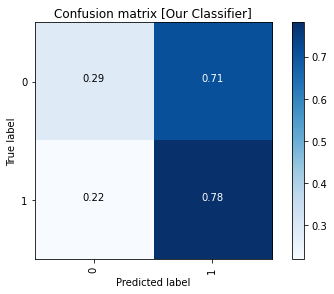

In [ ]:
from sklearn.metrics import confusion_matrix

cnf_matrix = confusion_matrix(TestData['Positive'].values.tolist(), TestData['Homebrew P Accurate'].values.tolist())

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize = True,
                      title='Confusion matrix [Our Classifier]')


Normalized confusion matrix


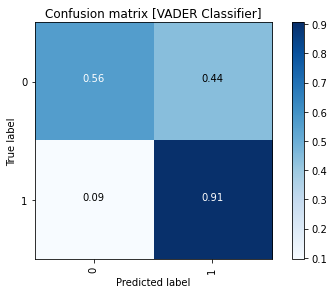

In [ ]:

cnf_matrix = confusion_matrix(TestData['Positive'].values.tolist(), TestData['Vader Accurate'].values.tolist())

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize = True,
                      title='Confusion matrix [VADER Classifier]')

Our classifier may be more accurate on average, but it is classifying everything as "Positive" and therefore has a high "false Positive" rate. 